In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/cleaned_ecommerce_data.csv")

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [4]:
df['total_sales'].sum()

np.float64(2174510366.99)

In [5]:
monthly_sales = df.groupby('month_name')['total_sales'].sum()

monthly_sales

month_name
April        1.813089e+08
August       1.802800e+08
December     1.827571e+08
February     1.808808e+08
January      1.808645e+08
July         1.811508e+08
June         1.868726e+08
March        1.762304e+08
May          1.749543e+08
November     1.769606e+08
October      1.841260e+08
September    1.881243e+08
Name: total_sales, dtype: float64

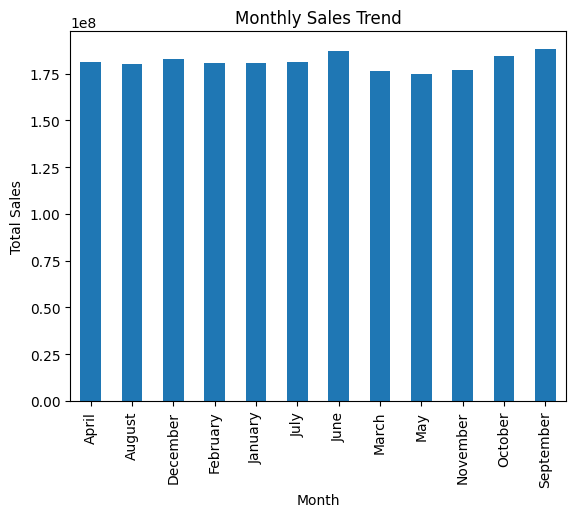

In [6]:
monthly_sales.plot(kind='bar')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [7]:
state_sales = df.groupby('state')['total_sales'].sum().sort_values(ascending=False)

state_sales.head(10)

state
Delhi NCR         1.956911e+08
Maharashtra       1.894436e+08
Karnataka         1.887672e+08
Kerala            1.683534e+08
Gujarat           1.682156e+08
Telangana         1.669118e+08
Tamil Nadu        1.654015e+08
Punjab            1.586658e+08
Haryana           1.572334e+08
Madhya Pradesh    1.312256e+08
Name: total_sales, dtype: float64

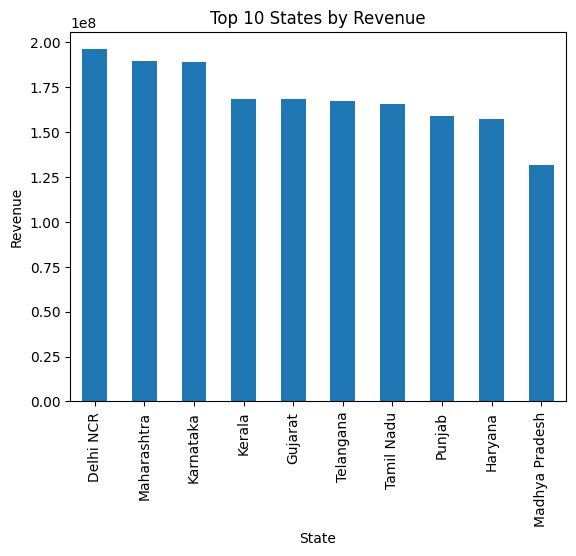

In [8]:
state_sales.head(10).plot(kind='bar')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

In [9]:
category_sales = df.groupby('category')['total_sales'].sum().sort_values(ascending=False)

category_sales

category
Premium Lifestyle         6.480969e+08
Electronics               5.205175e+08
Sports & Fitness          2.833666e+08
Home & Living             2.366783e+08
Footwear                  1.957683e+08
Fashion                   1.578753e+08
Beauty & Personal Care    1.016232e+08
Grocery Essentials        3.058428e+07
Name: total_sales, dtype: float64

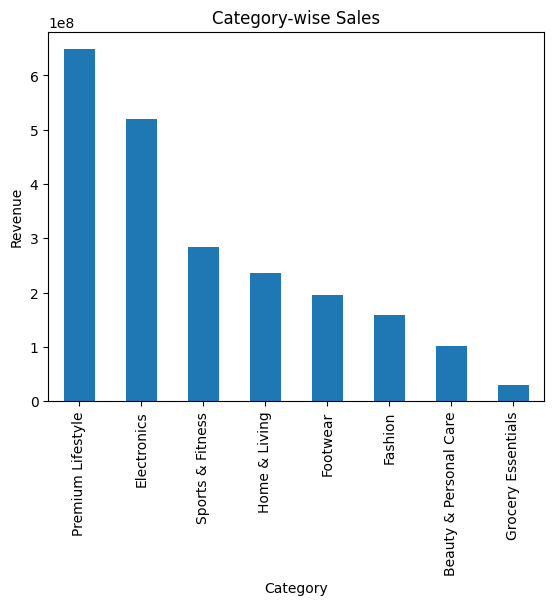

In [10]:
category_sales.plot(kind='bar')

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [11]:
gender_sales = df.groupby('customer_gender')['total_sales'].sum()

gender_sales

customer_gender
Female    1.088452e+09
Male      1.086058e+09
Name: total_sales, dtype: float64

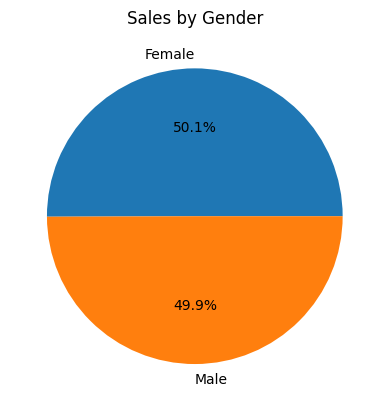

In [12]:
gender_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales by Gender")

plt.ylabel("")

plt.show()

In [13]:
df[['discount_percent', 'total_sales']].corr()

,discount_percent,total_sales
discount_percent,1.00000,-0.00714
total_sales,-0.00714,1.00000


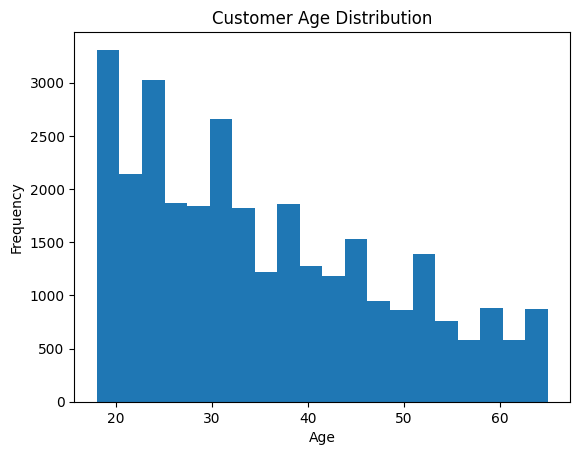

In [14]:
df['customer_age'].plot(kind='hist', bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [15]:
competition_sales = df.groupby('competition_intensity')['total_sales'].sum()

competition_sales

competition_intensity
High      5.460967e+08
Low       6.578965e+08
Medium    9.705171e+08
Name: total_sales, dtype: float64

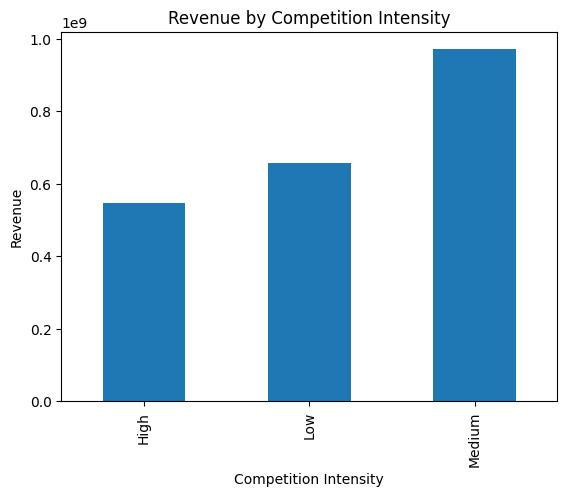

In [16]:
competition_sales.plot(kind='bar')

plt.title("Revenue by Competition Intensity")
plt.xlabel("Competition Intensity")
plt.ylabel("Revenue")

plt.show()

In [17]:
inventory_sales = df.groupby('inventory_pressure')['total_sales'].sum()

inventory_sales

inventory_pressure
High    6.410121e+08
Low     1.533498e+09
Name: total_sales, dtype: float64

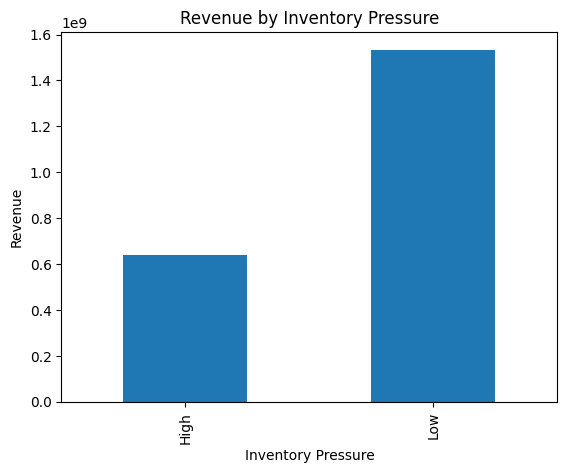

In [18]:
inventory_sales.plot(kind='bar')

plt.title("Revenue by Inventory Pressure")
plt.xlabel("Inventory Pressure")
plt.ylabel("Revenue")

plt.show()

In [19]:
kpi_summary = {
    'Total Revenue': df['total_sales'].sum(),
    'Total Orders': df['order_id'].nunique(),
    'Average Order Value': df['total_sales'].mean(),
    'Total Units Sold': df['units_sold'].sum(),
    'Average Discount': df['discount_percent'].mean()
}

kpi_summary

{'Total Revenue': np.float64(2174510366.99),
 'Total Orders': 30600,
 'Average Order Value': np.float64(71062.43029379084),
 'Total Units Sold': np.int64(970188),
 'Average Discount': np.float64(38.1112183006536)}

In [20]:
kpi_df = pd.DataFrame(kpi_summary.items(), columns=['KPI', 'Value'])

kpi_df

,KPI,Value
0,Total Revenue,2.174510e+09
1,Total Orders,3.060000e+04
2,Average Order Value,7.106243e+04
3,Total Units Sold,9.701880e+05
4,Average Discount,3.811122e+01


In [21]:
df.to_csv("data/final_cleaned_dataset.csv", index=False)

In [22]:
kpi_df.to_csv("reports/kpi_summary.csv", index=False)